In [1]:
from microscope.lasers import sapphire
from microscope.lights import omicron   
from microscope.controllers.yokogawa_csu import YokogawaCSU
from microscope.cameras.hamamatsu import HamamatsuCamera
import serial
import time

In [2]:
laser = sapphire.SapphireLaser(com='COM6')


In [3]:
laser.get_status()

['Laser status: Undefined',
 'Ligh Emission on? 0',
 'TEC Servo on? 1',
 'Key Switch on? ',
 'Target power: ',
 'Measured power: 1.127',
 'Head operating hours: 17649:04',
 '']

In [9]:
laser.shutdown()

In [2]:
omicron = Omicron.OmicronLaser(com='COM7')

Laser enabled
Key switch state
System power


In [3]:
omicron.ask_power()

20.0

In [6]:
omicron._do_shutdown()

Laser turned OFF.
Undefined
Undefined
Undefined


In [7]:
omicron = serial.Serial('COM7', baudrate=500000, timeout=0.5)

In [3]:
omicron.write('?GFw\r'.encode('ascii'))
time.sleep(0.5)
response = omicron.read_all()
print(response.decode('latin-1').strip())

!GFwLuxX§4§1.30


In [11]:
omicron.close()

In [8]:
def write(port, command: str) -> None:
    port.write(("?" + command + "\r").encode('ascii'))
    time.sleep(0.5)

def read(port) -> str:
    response = port.read_all().decode('latin-1').strip()
    if "!UK" in response:
        return 'UK'
    else:
        return response

def ask(port, command: str) -> str:
    """Send command and retrieve response."""
    write(port, command)
    response = read(port)
    if response == 'UK':
        print("Laser responded with 'Unknown command' to command '%s'" % command)
    response = response[len(command)+1:]
    return response

In [9]:
response = ask(omicron, "GFw")
response = response.split('§') # Remove the command echo
model = response[0]
device_id = int(response[1])
firmware = float(response[2])

In [59]:
sdc = serial.Serial('COM5', baudrate=115200, timeout=0.5)

In [57]:
sdc.write('SAVE_MEM\r'.encode('ascii'))
time.sleep(0.5)
response = sdc.read_all()
print(response.decode())

:A


In [61]:
sdc.write('BF_POS, ?\r'.encode('ascii'))
time.sleep(0.5)
response = sdc.read_all()
print(response)

b'NONE:A\r'


In [65]:
response.decode().strip()[:-2]

'NONE'

In [66]:
sdc.close()

In [2]:
csu = YokogawaCSU('COM5')

In [6]:
csu.devices

{'spinning_disk': <microscope.controllers.yokogawa_csu._YokogawaCSUSpinningDisk at 0x178426bf4d0>,
 'filterwheel': <microscope.controllers.yokogawa_csu._YokogawaCSUFilterWheel at 0x178426bf770>,
 'dichroic_mirror': <microscope.controllers.yokogawa_csu._YokogawaCSUDichroicMirror at 0x178426bf8c0>,
 'shutter': <microscope.controllers.yokogawa_csu._YokogawaCSUShutter at 0x178426bfa10>}

In [17]:
csu.devices['filterwheel'].get_info(4)

'561 FF01 602/36'

In [18]:
csu.shutdown()

In [2]:
camera = HamamatsuCamera('COM13')

In [3]:
import queue
import matplotlib.pyplot as plt

In [5]:
camera.set_exposure_time(0.1)

In [6]:
buffer = queue.Queue()
camera.set_client(buffer)
camera.enable()
for i in range(10):
    camera.trigger()
camera.disable()

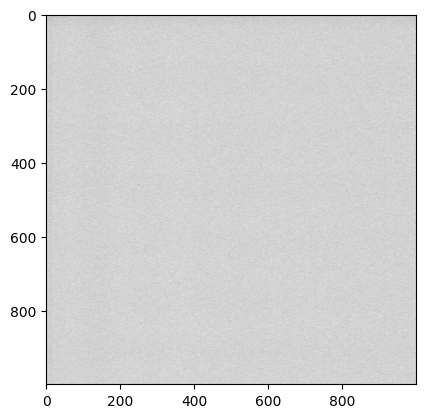

In [9]:
plt.imshow(buffer.get(0), cmap='gray')

In [4]:
camera.get_all_settings()

{'roi': None,
 'SENSOR MODE': 'AREA',
 'COLORTYPE': 'B/W',
 'BIT PER CHANNEL': 14,
 'OUTPUT DATA ORIENTATION': 'NORMAL',
 'OUTPUT DATA ROTATION': 0.0,
 'TRIGGER SOURCE': 'SOFTWARE',
 'TRIGGER MODE': 'NORMAL',
 'TRIGGER ACTIVE': 'EDGE',
 'TRIGGER POLARITY': 'NEGATIVE',
 'TRIGGER CONNECTOR': 'INTERFACE',
 'SENSITIVITY MODE': 'ON',
 'SENSITIVITY': 0.0,
 'EXPOSURE TIME': 0.03347,
 'CONTRAST OFFSET': 0,
 'BINNING': '1x1',
 'SUBARRAY HPOS': 0,
 'SUBARRAY HSIZE': 1000,
 'SUBARRAY VPOS': 0,
 'SUBARRAY VSIZE': 1000,
 'SUBARRAY MODE': 'OFF',
 'TIMING READOUT TIME': 0.03548354285714286,
 'TIMING CYCLIC TRIGGER PERIOD': 0.03332028571428571,
 'TIMING MIN TRIGGER BLANKING': 0.0026632571428571446,
 'TIMING MIN TRIGGER INTERVAL': 0.03397,
 'TIMING EXPOSURE': 'OVERLAP READOUT',
 'INTERNAL FRAME RATE': 28.06367085643908,
 'INTERNAL FRAME INTERVAL': 0.03563325714285715,
 'FRAMEBUNDLE MODE': 'OFF',
 'FRAMEBUNDLE NUMBER': 0,
 'FRAMEBUNDLE ROWBYTES': 2000,
 'FRAMEBUNDLE FRAME STEP BYTES': 0,
 'IMAGE WIDTH':

In [7]:
camera.set_setting('SENSITIVITY', 2)

In [8]:
camera.get_setting('SENSITIVITY')

2.0

In [9]:
camera.shutdown()

ignoring call to disable() because camera is already not capturing (CAP_STATUS is not BUSY)
